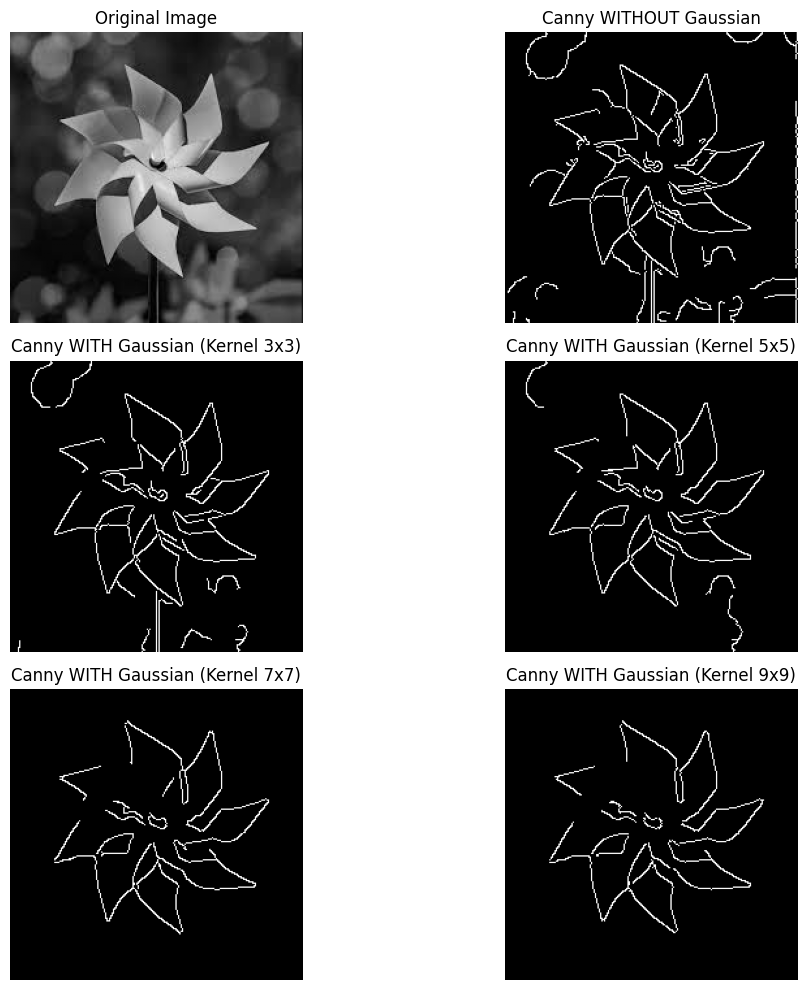

"\n# -----------------------------------------------------------------------------\n# 2. Manual Gaussian Blur\n# -----------------------------------------------------------------------------\ndef gaussian_kernel(size, sigma=1):\n    k = size // 2\n    x, y = np.mgrid[-k:k+1, -k:k+1]\n    normal = 1 / (2.0 * np.pi * sigma**2)\n    g = np.exp(-(x**2 + y**2) / (2 * sigma**2)) * normal\n    return g\n\ndef convolve(img, kernel):\n    kh, kw = kernel.shape\n    pad_h, pad_w = kh//2, kw//2\n    padded = np.pad(img, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant')\n    \n    out = np.zeros_like(img)\n    for i in range(img.shape[0]):\n        for j in range(img.shape[1]):\n            region = padded[i:i+kh, j:j+kw]\n            out[i, j] = np.sum(region * kernel)\n    return out\n\ngauss = gaussian_kernel(5, sigma=1.4)\nblurred = convolve(img, gauss)\n\n# -----------------------------------------------------------------------------\n# 3. Sobel Gradient (Manual)\n# -------------------------

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ---------- Load Image ----------
img = cv2.imread('Image/0.jpeg', 0)   # grayscale

# ---------- Canny Without Gaussian Smoothing ----------
edges_no_blur = cv2.Canny(img, 100, 200)

# ---------- Different Gaussian Kernel Sizes ----------
kernel_sizes = [3, 5, 7, 9]

edges_blurred = {}

for k in kernel_sizes:
    blurred = cv2.GaussianBlur(img, (k, k), 0)
    edges = cv2.Canny(blurred, 100, 200)
    edges_blurred[k] = edges

# ---------- Plotting ----------
plt.figure(figsize=(12, 10))

# Original
plt.subplot(3, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')

# Without Gaussian
plt.subplot(3, 2, 2)
plt.imshow(edges_no_blur, cmap='gray')
plt.title("Canny WITHOUT Gaussian")
plt.axis('off')

# Kernel size results
i = 3
for k in kernel_sizes:
    plt.subplot(3, 2, i)
    plt.imshow(edges_blurred[k], cmap='gray')
    plt.title(f"Canny WITH Gaussian (Kernel {k}x{k})")
    plt.axis('off')
    i += 1

plt.tight_layout()
plt.show()


'''
# -----------------------------------------------------------------------------
# 2. Manual Gaussian Blur
# -----------------------------------------------------------------------------
def gaussian_kernel(size, sigma=1):
    k = size // 2
    x, y = np.mgrid[-k:k+1, -k:k+1]
    normal = 1 / (2.0 * np.pi * sigma**2)
    g = np.exp(-(x**2 + y**2) / (2 * sigma**2)) * normal
    return g

def convolve(img, kernel):
    kh, kw = kernel.shape
    pad_h, pad_w = kh//2, kw//2
    padded = np.pad(img, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant')
    
    out = np.zeros_like(img)
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            region = padded[i:i+kh, j:j+kw]
            out[i, j] = np.sum(region * kernel)
    return out

gauss = gaussian_kernel(5, sigma=1.4)
blurred = convolve(img, gauss)

# -----------------------------------------------------------------------------
# 3. Sobel Gradient (Manual)
# -----------------------------------------------------------------------------
Sx = np.array([[-1,0,1],[-2,0,2],[-1,0,1]])
Sy = np.array([[1,2,1],[0,0,0],[-1,-2,-1]])

Gx = convolve(blurred, Sx)
Gy = convolve(blurred, Sy)

magnitude = np.sqrt(Gx**2 + Gy**2)
magnitude = magnitude / magnitude.max() * 255

theta = np.arctan2(Gy, Gx)

# -----------------------------------------------------------------------------
# 4. Non-Maximum Suppression
# -----------------------------------------------------------------------------
def non_max_suppression(mag, angle):
    Z = np.zeros_like(mag)
    angle = angle * 180.0 / np.pi
    angle[angle < 0] += 180
    
    for i in range(1, mag.shape[0]-1):
        for j in range(1, mag.shape[1]-1):
            q = 255
            r = 255
            
            # angle 0
            if (0 <= angle[i,j] < 22.5) or (157.5 <= angle[i,j] <= 180):
                q = mag[i, j+1]
                r = mag[i, j-1]
            # angle 45
            elif (22.5 <= angle[i,j] < 67.5):
                q = mag[i+1, j-1]
                r = mag[i-1, j+1]
            # angle 90
            elif (67.5 <= angle[i,j] < 112.5):
                q = mag[i+1, j]
                r = mag[i-1, j]
            # angle 135
            elif (112.5 <= angle[i,j] < 157.5):
                q = mag[i-1, j-1]
                r = mag[i+1, j+1]

            if (mag[i,j] >= q) and (mag[i,j] >= r):
                Z[i,j] = mag[i,j]
            else:
                Z[i,j] = 0
    return Z

nms = non_max_suppression(magnitude, theta)

# -----------------------------------------------------------------------------
# 5. Double Thresholding
# -----------------------------------------------------------------------------
low = 30
high = 90

strong = 255
weak = 75

res = np.zeros_like(nms)
strong_i, strong_j = np.where(nms >= high)
weak_i, weak_j = np.where((nms <= high) & (nms >= low))

res[strong_i, strong_j] = strong
res[weak_i, weak_j] = weak

# -----------------------------------------------------------------------------
# 6. Hysteresis Edge Tracking
# -----------------------------------------------------------------------------
def hysteresis(img):
    H, W = img.shape
    for i in range(1, H-1):
        for j in range(1, W-1):
            if img[i,j] == weak:
                if ((img[i+1, j-1] == strong) or (img[i+1, j] == strong) or 
                    (img[i+1, j+1] == strong) or (img[i, j-1] == strong) or
                    (img[i, j+1] == strong) or (img[i-1, j-1] == strong) or 
                    (img[i-1, j] == strong) or (img[i-1, j+1] == strong)):
                    img[i,j] = strong
                else:
                    img[i,j] = 0
    return img

final_edges = hysteresis(res)
'''